# Pretrained atomistic models as featurizers in `mlcolvar`
[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/luigibonati/mlcolvar/blob/main/docs/notebooks/tutorials/adv_integrations.ipynb)

Prerequisites:
- This is an advanced tutorial. It assumes that you are already familiar with the basic `mlcolvar` tutorials on data loading, training CVs, and graph-based CVs.
- The example uses alanine-dipeptide trajectories stored in `data/alanine_gnn`.
- Optional dependencies are required only for the backend selected below.

Author: Kai Zhu

---


### Colab setup

This notebook is intended primarily for a local development installation, because the atomistic backends rely on optional packages such as `mace-torch`, `metatrain`, `metatomic`, or `deepmd-kit`. If you run it in Colab, install the matching optional dependency before selecting the corresponding backend.


In [1]:
# Colab setup
import os

if os.getenv("COLAB_RELEASE_TAG"):
    import subprocess

    subprocess.run(
        "wget https://raw.githubusercontent.com/luigibonati/mlcolvar/main/colab_setup.sh",
        shell=True,
        check=True,
    )
    cmd = subprocess.run(
        "bash colab_setup.sh TUTORIAL",
        shell=True,
        check=True,
        stdout=subprocess.PIPE,
    )
    print(cmd.stdout.decode("utf-8"))


## Overview

This tutorial shows how to use a pretrained atomistic model as a frozen feature extractor for learning collective variables (CVs) in `mlcolvar`.

The same workflow is demonstrated for three supported backends:

| Backend | Adapter | Example model | Extra dependency |
|---|---|---|---|
| MACE | `MACEBackbone` | MACE-MP small | `mace-torch` |
| PET | `PETBackbone` | PET-MAD | `metatrain`, `metatomic`, `metatensor` |
| DeePMD-kit | `DeepMDBackbone` | local DPA-2 checkpoint | `deepmd-kit` with PyTorch support |

Only the model-loading step is backend-specific. After that, the same objects are used for dataset construction, element alignment, pooling, CV training, and model export.

The workflow is:

1. choose a pretrained backend;
2. wrap it as a model-specific `Backbone`;
3. pass the backbone to `AtomisticFeaturizer`;
4. align the dataset element encoding to the pretrained model;
5. train a lightweight readout with a standard CV method;
6. export and validate the inference model.

> Run the notebook once for each backend you want to test. Restart the kernel before changing `BACKBONE_NAME`, because different pretrained models may use different default precisions.

---


## 1. Common architecture

All integrations follow the same three-layer design:

```text
external pretrained model
        │
        ▼
model-specific backbone
MACEBackbone / PETBackbone / DeepMDBackbone
        │
        │ atom-level or system-level features
        ▼
AtomisticFeaturizer
        │
        │ freezing, validation, masking, and pooling
        ▼
graph-level representation
        │
        ▼
AtomisticModel
        │
        │ trainable feed-forward readout
        ▼
collective variable
```

The pretrained parameters can remain frozen while derivatives of the CV with respect to atomic coordinates are preserved. This is essential when the CV is later used to apply enhanced-sampling forces.


## 2. Select the backend and global settings

Set `BACKBONE_NAME` to one of `"mace"`, `"pet"`, or `"deepmd"`. The rest of the notebook is shared across backends.


In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import torch

# Reproducibility for the trainable readout.
torch.manual_seed(41)

# Select one of: "mace", "pet", or "deepmd".
BACKBONE_NAME = "mace"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
DATA_DIR = Path("./data/alanine_gnn")

BATCH_SIZE = 32
MAX_EPOCHS = 1

print("Selected backend:", BACKBONE_NAME)
print("Device:", DEVICE)
print("Dataset directory:", DATA_DIR.resolve())


Selected backend: mace
Device: cuda
Dataset directory: /home/kzhu-iit.local/data/mlcolvar-premodel/docs/notebooks/tutorials/data/alanine_gnn


## 3. Load the pretrained model

The following cell contains the only backend-specific part of the tutorial. Each branch creates:

- `backbone`: a model-specific adapter that extracts a standardized atomistic representation;
- `featurizer`: a backend-independent wrapper that freezes the pretrained model and pools atom-level features into graph-level features.

Here we use `pooling="mean"`, which makes the representation less directly dependent on the number of selected atoms. Use `"sum"` if an extensive representation is more appropriate for your application.


In [3]:
from mlcolvar.integrations import AtomisticFeaturizer

BACKBONE_NAME = BACKBONE_NAME.lower()

if BACKBONE_NAME == "mace":
    # MACE-MP models used here operate in float32.
    torch.set_default_dtype(torch.float32)

    from mace.calculators import mace_mp
    from mlcolvar.integrations import MACEBackbone

    calculator = mace_mp(
        model="small",
        device=DEVICE,
        default_dtype="float32",
    )
    pretrained_model = calculator.models[0]
    pretrained_model.eval()

    backbone = MACEBackbone(model=pretrained_model)

elif BACKBONE_NAME == "pet":
    # PET-MAD is loaded through the metatrain/metatomic interface.
    torch.set_default_dtype(torch.float64)

    from metatrain.utils.io import load_model
    from mlcolvar.integrations import PETBackbone

    PET_MAD_URL = (
        "https://huggingface.co/lab-cosmo/pet-mad/"
        "resolve/v1.0.2/models/pet-mad-v1.0.2.ckpt"
    )

    pretrained_model = load_model(PET_MAD_URL)
    pretrained_model = pretrained_model.to(
        device=DEVICE,
        dtype=torch.float64,
    )
    pretrained_model.eval()

    backbone = PETBackbone(model=pretrained_model)

elif BACKBONE_NAME == "deepmd":
    # The DPA-2 checkpoint must be downloaded separately.
    torch.set_default_dtype(torch.float32)

    from deepmd.pt.model.model.model import BaseModel
    from deepmd.pt.utils.serialization import serialize_from_file
    from mlcolvar.integrations import DeepMDBackbone

    DPA2_MODEL_PATH = Path("./models/DPA-2.4-7M-SPICE2.pth")

    if not DPA2_MODEL_PATH.exists():
        raise FileNotFoundError(
            "DPA-2 checkpoint not found. Update DPA2_MODEL_PATH "
            "before running the DeePMD example."
        )

    serialized_model = serialize_from_file(str(DPA2_MODEL_PATH))
    pretrained_model = BaseModel.deserialize(serialized_model["model"])
    pretrained_model = pretrained_model.to(
        device=DEVICE,
        dtype=torch.float32,
    )
    pretrained_model.eval()

    backbone = DeepMDBackbone(model=pretrained_model)

else:
    raise ValueError(
        "BACKBONE_NAME must be 'mace', 'pet', or 'deepmd', "
        f"found {BACKBONE_NAME!r}."
    )

featurizer = AtomisticFeaturizer(
    backbone=backbone,
    pooling="mean",
    freeze=True,
)

print("Backbone:", type(backbone).__name__)
print("Feature dimension:", backbone.out_features)
print("Sample kind:", backbone.sample_kind)
print("Atomic numbers:", backbone.atomic_numbers.detach().cpu().tolist())
print("Cutoff:", float(backbone.cutoff.detach().cpu().item()))
print("Frozen:", featurizer.freeze)


/home/kzhu-iit.local/miniconda3/envs/mlcolvar-gnn/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
To get the best performance, it is recommended to adjust the number of threads by setting the environment variables OMP_NUM_THREADS, DP_INTRA_OP_PARALLELISM_THREADS, and DP_INTER_OP_PARALLELISM_THREADS. See https://deepmd.rtfd.io/parallelism/ for more information.
/home/kzhu-iit.local/miniconda3/envs/mlcolvar-gnn/lib/python3.11/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))
/home/kzhu-iit.local/miniconda3/envs/mlcolvar-gnn/lib/python3.11/si

cuequivariance or cuequivariance_torch is not available. Cuequivariance acceleration will be disabled.
Using Materials Project MACE for MACECalculator with /home/kzhu-iit.local/.cache/mace/20231210mace128L0_energy_epoch249model
Using float32 for MACECalculator, which is faster but less accurate. Recommended for MD. Use float64 for geometry optimization.


Backbone: MACEBackbone
Feature dimension: 256
Sample kind: atom
Atomic numbers: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 89, 90, 91, 92, 93, 94]
Cutoff: 6.0
Frozen: True


### Backend-specific notes

#### MACE

`MACEBackbone` extracts the pretrained node representation exposed by MACE. The MACE-MP **small** model is used here to keep the example lightweight.

#### PET

`PETBackbone` converts the `mlcolvar` graph batch into metatomic systems and extracts PET features. PET may use a different internal precision from the trainable readout; `AtomisticModel` handles the feature conversion without disconnecting coordinate gradients.

#### DeePMD-kit

`DeepMDBackbone` uses the descriptor of a serialized DeePMD PyTorch model. The element order is taken from the model type map, and the local checkpoint path must be provided explicitly.


## 4. Construct the graph dataset

The pretrained model determines both the neighbor-list cutoff and the required element table. We therefore build the graph dataset using the standardized cutoff stored by the selected backbone.

MDTraj stores coordinates in nanometers, whereas the pretrained models used here expect ångström. Therefore, `lengths_conversion=10.0` is used.

The progress bar is disabled to keep the notebook file small and easy to review on GitHub.


In [4]:
from mlcolvar.io import create_dataset_from_trajectories

if not DATA_DIR.exists():
    raise FileNotFoundError(
        f"Dataset directory not found: {DATA_DIR.resolve()}"
    )

load_args = [
    {"start": 0, "stop": 10000, "stride": 5},
    {"start": 0, "stop": 10000, "stride": 5},
]

model_cutoff = float(
    featurizer.cutoff.detach().cpu().item()
)

dataset = create_dataset_from_trajectories(
    trajectories=[
        "alad_A.trr",
        "alad_B.trr",
    ],
    topologies="alad.gro",
    folder=str(DATA_DIR),
    cutoff=model_cutoff,
    system_selection="all",
    show_progress=False,
    load_args=load_args,
    lengths_conversion=10.0,
)

print("Dataset information:")
print(dataset)
print("\nDataset metadata:")
print(dataset.metadata)


/home/kzhu-iit.local/data/mlcolvar-premodel/mlcolvar/data/graph/utils.py:86: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  graph_labels = torch.tensor( config.graph_labels, dtype=torch.get_default_dtype() )   if config.graph_labels is not None else None


Dataset information:
DictDataset( "data_list": 4000,
	    metadata={"atomic_numbers": [1, 6, 7, 8],
		      "cutoff": 6.0,
		      "buffer": 0.0,
		      "long_range_cutoff": -1.0,
		      "system_idx": tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21]),
		      "system_atoms_names": [ACE1-H1, ACE1-CH3, ACE1-H2, ACE1-H3, ACE1-C, ACE1-O, ALA2-N, ALA2-H, ALA2-CA, ALA2-HA, ALA2-CB, ALA2-HB1, ALA2-HB2, ALA2-HB3, ALA2-C, ALA2-O, NME3-N, NME3-H, NME3-C, NME3-H1, NME3-H2, NME3-H3],
		      "is_truncated_graph": False,
		      "data_type": graphs } )

Dataset metadata:
{'atomic_numbers': [1, 6, 7, 8], 'cutoff': 6.0, 'buffer': 0.0, 'long_range_cutoff': -1.0, 'system_idx': tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21]), 'system_atoms_names': [ACE1-H1, ACE1-CH3, ACE1-H2, ACE1-H3, ACE1-C, ACE1-O, ALA2-N, ALA2-H, ALA2-CA, ALA2-HA, ALA2-CB, ALA2-HB1, ALA2-HB2, ALA2-HB3, ALA2-C, ALA2-O, NME

## 5. Align the element encoding

Graph datasets store atomic species in `node_attrs`, typically as one-hot vectors. Their column order must match the element order expected by the pretrained model.

For example, a dataset encoded as `[H, O, C, N]` cannot be passed directly to a model trained with `[H, C, N, O]`, even if both contain the same chemical elements. `align_dataset()` rebuilds the node attributes in the order required by the selected backbone.


In [5]:
print(
    "Dataset atomic numbers before alignment:",
    dataset.metadata["atomic_numbers"],
)

dataset = featurizer.align_dataset(dataset)
example_graph = dataset["data_list"][0]

print(
    "Dataset atomic numbers after alignment:",
    dataset.metadata["atomic_numbers"],
)
print("node_attrs shape:", example_graph["node_attrs"].shape)
print("Backbone element count:", backbone.atomic_numbers.numel())

assert (
    example_graph["node_attrs"].shape[-1]
    == backbone.atomic_numbers.numel()
)
assert (
    len(dataset.metadata["atomic_numbers"])
    == backbone.atomic_numbers.numel()
)


Dataset atomic numbers before alignment: [1, 6, 7, 8]
Dataset atomic numbers after alignment: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 89, 90, 91, 92, 93, 94]
node_attrs shape: torch.Size([22, 89])
Backbone element count: 89


## 6. Create the data module

`DictModule` batches the graph dictionaries while preserving the information needed by the atomistic backbone, including atomic positions, graph assignments, cells, neighbor lists, and node attributes.


In [6]:
from mlcolvar.data import DictModule

datamodule = DictModule(
    dataset=dataset,
    batch_size=BATCH_SIZE,
)

print("Datamodule information:")
print(datamodule)


Datamodule information:
DictModule(dataset -> DictDataset( "data_list": 4000,
	    metadata={"atomic_numbers": [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 89, 90, 91, 92, 93, 94],
		      "cutoff": 6.0,
		      "buffer": 0.0,
		      "long_range_cutoff": -1.0,
		      "system_idx": tensor([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
        18, 19, 20, 21]),
		      "system_atoms_names": [ACE1-H1, ACE1-CH3, ACE1-H2, ACE1-H3, ACE1-C, ACE1-O, ALA2-N, ALA2-H, ALA2-CA, ALA2-HA, ALA2-CB, ALA2-HB1, ALA2-HB2, ALA2-HB3, ALA2-C, ALA2-O, NME3-N, NME3-H, NME3-C, NME3-H1, NME3-H2, NME3-H3],
		      "is_truncated_graph": False,
		      "data_type": graphs } ),
	     train_loader -> DictLoader(len

## 7. Build a trainable CV readout

`AtomisticModel` combines the frozen featurizer with a trainable feed-forward readout:

```text
atomic graph
    → frozen pretrained representation
    → atom-to-system pooling
    → trainable MLP
    → CV
```

Here the model is used as the neural-network component of `DeepTDA`. The two metastable states are assigned target centers at `-7` and `7`.


In [7]:
from mlcolvar.cvs import DeepTDA
from mlcolvar.integrations import AtomisticModel

atomistic_cv = AtomisticModel(
    featurizer=featurizer,
    n_out=1,
    hidden_layers=(32, 32),
)

model = DeepTDA(
    n_states=2,
    n_cvs=1,
    target_centers=[-7.0, 7.0],
    target_sigmas=[0.2, 0.2],
    model=atomistic_cv,
)

print(model)


DeepTDA(
  (loss_fn): TDALoss()
  (nn): AtomisticModel(
    (featurizer): AtomisticFeaturizer(
      (backbone): MACEBackbone(
        (model): ScaleShiftMACE(
          (node_embedding): LinearNodeEmbeddingBlock(
            (linear): Linear(89x0e -> 128x0e | 11392 weights)
          )
          (radial_embedding): RadialEmbeddingBlock(
            (bessel_fn): BesselBasis(r_max=6.0, num_basis=10, trainable=False)
            (cutoff_fn): PolynomialCutoff(p=5.0, r_max=6.0)
          )
          (spherical_harmonics): SphericalHarmonics()
          (atomic_energies_fn): AtomicEnergiesBlock(energies=[[-3.6672, -1.3321, -3.4821, -4.7367, -7.7249, -8.4056, -7.3601, -7.2846, -4.8965, 0.0000, -2.7594, -2.8140, -4.8469, -7.6948, -6.9633, -4.6726, -2.8117, -0.0626, -2.6176, -5.3905, -7.8858, -10.2684, -8.6651, -9.2331, -8.3050, -7.0490, -5.5774, -5.1727, -3.2521, -1.2902, -3.5271, -4.7085, -3.9765, -3.8862, -2.5185, 6.7669, -2.5635, -4.9380, -10.1498, -11.8469, -12.1389, -8.7917, -8.7869, -7.

/home/kzhu-iit.local/miniconda3/envs/mlcolvar-gnn/lib/python3.11/site-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'model' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['model'])`.


### Frozen parameters and coordinate gradients

Freezing the backbone sets `requires_grad=False` only for its parameters. It does **not** wrap the forward pass in `torch.no_grad()`. Therefore, derivatives of the CV with respect to atomic coordinates remain available for computing enhanced-sampling forces.


In [8]:
backbone_parameters = list(
    model.nn.featurizer.backbone.parameters()
)
readout_parameters = list(
    model.nn.readout.parameters()
)

print(
    "All backbone parameters frozen:",
    all(not parameter.requires_grad for parameter in backbone_parameters),
)
print(
    "All readout parameters trainable:",
    all(parameter.requires_grad for parameter in readout_parameters),
)

n_backbone = sum(
    parameter.numel()
    for parameter in backbone_parameters
)
n_readout = sum(
    parameter.numel()
    for parameter in readout_parameters
)

print("Backbone parameters:", n_backbone)
print("Trainable readout parameters:", n_readout)


All backbone parameters frozen: True
All readout parameters trainable: True
Backbone parameters: 3847696
Trainable readout parameters: 9313


## 8. Train the CV

The number of epochs is intentionally small so that the notebook runs quickly. Increase `MAX_EPOCHS` and use proper training/validation settings for production applications.


In [9]:
from lightning import Trainer

from mlcolvar.utils.trainer import MetricsCallback

metrics = MetricsCallback()

trainer = Trainer(
    max_epochs=MAX_EPOCHS,
    logger=False,
    enable_checkpointing=False,
    enable_model_summary=False,
    callbacks=[metrics],
)

trainer.fit(model, datamodule)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Sanity Checking DataLoader 0:   0%|          | 0/2 [00:00<?, ?it/s]

/home/kzhu-iit.local/miniconda3/envs/mlcolvar-gnn/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:485: Your `val_dataloader`'s sampler has shuffling enabled, it is strongly recommended that you turn shuffling off for val/test dataloaders.
/home/kzhu-iit.local/miniconda3/envs/mlcolvar-gnn/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.


Sanity Checking DataLoader 0:  50%|█████     | 1/2 [00:00<00:00,  2.73it/s]

/home/kzhu-iit.local/miniconda3/envs/mlcolvar-gnn/lib/python3.11/site-packages/lightning/pytorch/utilities/data.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 2. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.


/home/kzhu-iit.local/miniconda3/envs/mlcolvar-gnn/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/home/kzhu-iit.local/miniconda3/envs/mlcolvar-gnn/lib/python3.11/site-packages/lightning/pytorch/loops/fit_loop.py:534: Found 89 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is intentional, you can ignore this warning.


Epoch 49: 100%|██████████| 100/100 [00:07<00:00, 12.89it/s]

`Trainer.fit` stopped: `max_epochs=50` reached.


Epoch 49: 100%|██████████| 100/100 [00:07<00:00, 12.88it/s]


## 9. Inspect the training curves

The `MetricsCallback` stores the training and validation losses in a dictionary that can be passed directly to `plot_metrics`.


{'epoch': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49], 'train_loss': [100.42920684814453, 84.06555938720703, 69.56773376464844, 58.92314910888672, 49.742103576660156, 44.38303756713867, 41.44916534423828, 38.49851989746094, 33.945125579833984, 35.151824951171875, 35.730613708496094, 27.007463455200195, 28.581581115722656, 24.245981216430664, 23.455341339111328, 23.560623168945312, 23.428869247436523, 18.34892463684082, 16.951549530029297, 19.04691505432129, 18.139856338500977, 20.230426788330078, 14.473623275756836, 17.37019920349121, 15.515159606933594, 13.97958755493164, 16.312557220458984, 15.66032600402832, 11.515925407409668, 9.776496887207031, 11.855083465576172, 11.429071426391602, 9.174300193786621, 11.081551551818848, 7.082737445831299, 12.588647842407227, 14.652706146240234, 5.064111232757568, 5.605760097503662, 5.583456993103027, 

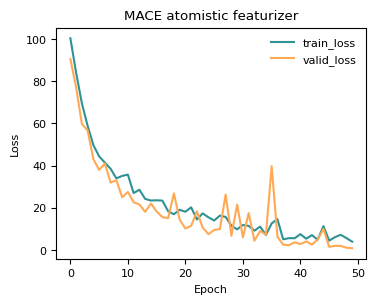

In [10]:
from mlcolvar.utils.plot import plot_metrics

print(metrics.metrics)

fig, ax = plt.subplots(
    1,
    1,
    figsize=(4, 3),
)

plot_metrics(
    metrics.metrics,
    keys=["train_loss", "valid_loss"],
    colors=["fessa1", "fessa5"],
    yscale="linear",
    ax=ax,
)

ax.set_title(
    f"{BACKBONE_NAME.upper()} atomistic featurizer"
)
plt.show()


## 10. Export the inference model

For deployment in an MD or enhanced-sampling workflow, export the inference network rather than the complete Lightning training module.

MACE contains `e3nn` modules and is scripted with `e3nn.util.jit.script`. PET and DeePMD-kit can use standard `torch.jit.script`.


In [11]:
model.eval()

inference_model = model.nn.eval().cpu()

if BACKBONE_NAME == "mace":
    from e3nn.util import jit as e3nn_jit

    scripted_model = e3nn_jit.script(
        inference_model,
        in_place=False,
    )
else:
    scripted_model = torch.jit.script(
        inference_model
    )

EXPORT_PATH = Path(
    f"deep_tda_{BACKBONE_NAME}_atomistic.pt"
)

torch.jit.save(
    scripted_model,
    str(EXPORT_PATH),
)

print("Saved model to:", EXPORT_PATH.resolve())


/home/kzhu-iit.local/miniconda3/envs/mlcolvar-gnn/lib/python3.11/site-packages/torch/jit/_check.py:178: UserWarning: The TorchScript type system doesn't support instance-level annotations on empty non-base types in `__init__`. Instead, either 1) use a type annotation in the class body, or 2) wrap the type in `torch.jit.Attribute`.
  warnings.warn(


Saved model to: /home/kzhu-iit.local/data/mlcolvar-premodel/docs/notebooks/tutorials/deep_tda_mace_atomistic.pt


## 11. Check the serialized model

A simple numerical comparison verifies that serialization has not changed the model output. The expected batch key is `data_list`, matching the graph datasets created by `create_dataset_from_trajectories`.


In [12]:
def move_to_device(obj, device):
    """Recursively move tensors in a nested graph batch."""

    if isinstance(obj, torch.Tensor):
        return obj.to(device)

    if isinstance(obj, dict):
        return {
            key: move_to_device(value, device)
            for key, value in obj.items()
        }

    if isinstance(obj, list):
        return [
            move_to_device(value, device)
            for value in obj
        ]

    if isinstance(obj, tuple):
        return tuple(
            move_to_device(value, device)
            for value in obj
        )

    return obj


# Use CPU consistently for TorchScript validation.
validation_device = torch.device("cpu")

# The original inference model may still be on CUDA after training.
inference_model = inference_model.to(
    validation_device
)
inference_model.eval()

# Load the serialized model directly onto CPU.
loaded_model = torch.jit.load(
    str(EXPORT_PATH),
    map_location=validation_device,
)
loaded_model.eval()

# Obtain one validation batch.
datamodule.setup()
batch = next(
    iter(datamodule.val_dataloader())
)

# Move every tensor inside the graph dictionary to CPU.
graph = move_to_device(
    batch["data_list"],
    validation_device,
)

with torch.no_grad():
    reference = inference_model(graph)
    restored = loaded_model(graph)

maximum_error = torch.max(
    torch.abs(reference - restored)
).item()

print("Reference device:", reference.device)
print("Restored device:", restored.device)
print("Reference shape:", reference.shape)
print("Restored shape:", restored.shape)
print("Maximum absolute error:", maximum_error)


Reference device: cpu
Restored device: cpu
Reference shape: torch.Size([32, 1])
Restored shape: torch.Size([32, 1])
Maximum absolute error: 0.0


## 12. Summary

The three integrations differ only in how the pretrained model is loaded and how its native representation is extracted. The downstream `mlcolvar` workflow is shared.

| Property | MACE | PET | DeePMD-kit |
|---|---|---|---|
| Adapter | `MACEBackbone` | `PETBackbone` | `DeepMDBackbone` |
| Example model | MACE-MP small | PET-MAD | DPA-2 |
| Model source | automatic download | URL through `metatrain` | local checkpoint |
| Common wrapper | `AtomisticFeaturizer` | `AtomisticFeaturizer` | `AtomisticFeaturizer` |
| Common CV head | `AtomisticModel` | `AtomisticModel` | `AtomisticModel` |
| Coordinate gradients | preserved | preserved | preserved |
| Frozen-model mode | supported | supported | supported |

The reusable pattern is:

```python
backbone = ModelSpecificBackbone(model=pretrained_model)

featurizer = AtomisticFeaturizer(
    backbone=backbone,
    pooling="mean",
    freeze=True,
)

graph_model = AtomisticModel(
    featurizer=featurizer,
    n_out=1,
    hidden_layers=(32, 32),
)
```

This separation keeps optional external dependencies outside the core CV implementation while providing a consistent interface for transfer learning with pretrained atomistic representations.
